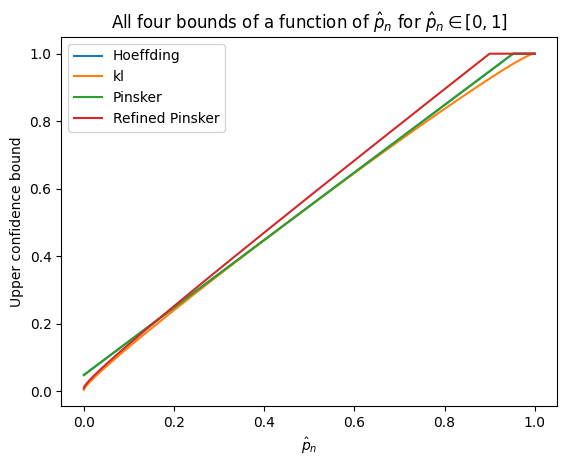

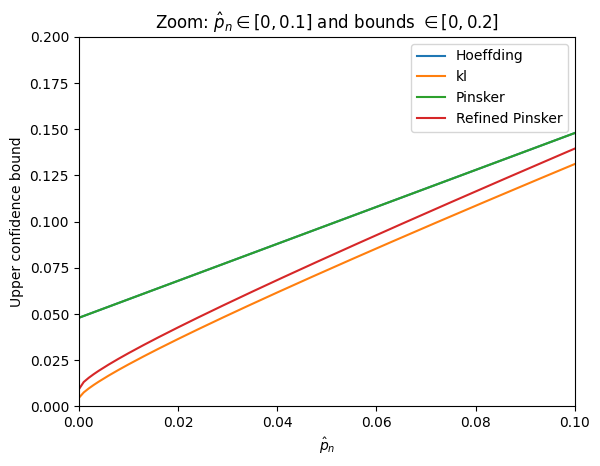

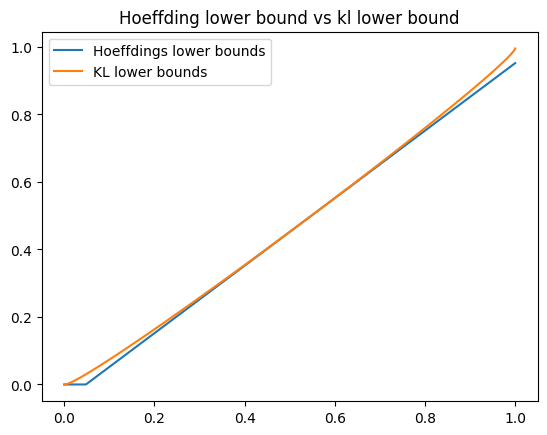

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

# Hoeffding's inequality
def hoeffding(n=1000, delta=0.01):
    return np.sqrt((np.log(1/delta)) / (2*n))

# Binary kl-divergence
def kl_div(p_hat, q):
    if p_hat == 0:
        first_term = 0.0
    else:
        first_term = p_hat*np.log(p_hat/q)
    if p_hat == 1:
        second_term = 0.0
    else:
        second_term = (1 - p_hat)*np.log((1 - p_hat) / (1 - q))
    return first_term + second_term 

# kl epsilon
def kl_epsilon(n=1000, delta=0.01):
    return np.log(1/delta) / n 

# Unique solution via binary search
def kl_upper(p_hat, n=1000, delta=0.01, tol=1e-10):
    if p_hat == 1.0:
        return 1.0
    epsilon = kl_epsilon(n, delta)
    lower, upper = p_hat, 1 
    while (upper - lower) > tol:
        mid = (upper + lower) / 2
        div = kl_div(p_hat, mid)
        if div > epsilon:
            upper = mid 
        else:
            lower = mid 
    return lower


def pinsker(p_hat, n=1000, delta=0.01):
    return p_hat + np.sqrt((np.log(1/delta)) / (2*n))

def refined_pinskers(p_hat, n=1000, delta=0.01):
    first_term = p_hat + np.sqrt((2*p_hat*np.log(1/delta)) / (n))
    second_term = 2* ((np.log(1/delta)) / (n))
    return first_term + second_term

p_hats = np.linspace(0, 1, 1000)
hoeffding_bounds = p_hats + hoeffding()
kl_bounds = [kl_upper(p) for p in p_hats]
pinsker_bounds = [pinsker(p) for p in p_hats]
refined_pinsker_bounds = [refined_pinskers(p) for p in p_hats]

hoeffding_bounds = np.clip(hoeffding_bounds, 0, 1)
kl_bounds = np.clip(kl_bounds, 0, 1)
pinsker_bounds = np.clip(pinsker_bounds, 0, 1)
refined_pinsker_bounds = np.clip(refined_pinsker_bounds, 0, 1)


plt.plot(p_hats, hoeffding_bounds, label=r"Hoeffding")
plt.plot(p_hats, kl_bounds, label=r"kl")
plt.plot(p_hats, pinsker_bounds, label=r"Pinsker")
plt.plot(p_hats, refined_pinsker_bounds, label=r"Refined Pinsker")
plt.legend()
plt.ylabel(r"Upper confidence bound")
plt.xlabel(r"$\hat{p}_{n}$")
plt.title(r"All four bounds of a function of $\hat{p}_{n}$ for $\hat{p}_{n} \in [0, 1]$")
plt.show()

# Zoomed in plot 
plt.plot(p_hats, hoeffding_bounds, label=r"Hoeffding")
plt.plot(p_hats, kl_bounds, label=r"kl")
plt.plot(p_hats, pinsker_bounds, label=r"Pinsker")
plt.plot(p_hats, refined_pinsker_bounds, label=r"Refined Pinsker")
plt.legend()
plt.ylabel(r"Upper confidence bound")
plt.xlabel(r"$\hat{p}_{n}$")
plt.title(r"Zoom: $\hat p_n\in[0,0.1]$ and bounds $\in [0, 0.2]$")
plt.xlim(0.0, 0.1)
plt.ylim(0.0, 0.2)
plt.show()


# Unique solution via binary search
def kl_lower(p_hat, n=1000, delta=0.01, tol=1e-10):
    if p_hat == 0.0:
        return 0.0
    epsilon = kl_epsilon(n, delta)
    lower, upper = 0, p_hat
    while (upper - lower) > tol:
        mid = (upper + lower) / 2
        div = kl_div(p_hat, mid)
        if div > epsilon:
            lower = mid 
        else:
            upper = mid 
    return upper

hoeffding_lower_bounds = p_hats - hoeffding()
kl_lower_bounds = [kl_lower(p) for p in p_hats]
hoeffding_lower_bounds = np.clip(hoeffding_lower_bounds, 0, 1)
kl_lower_bounds = np.clip(kl_lower_bounds, 0, 1)

plt.plot(p_hats, hoeffding_lower_bounds, label="Hoeffdings lower bounds")
plt.plot(p_hats, kl_lower_bounds, label="KL lower bounds")
plt.title(r"Hoeffding lower bound vs kl lower bound")
plt.legend()
plt.show()

In [15]:
small_p = np.linspace(0, 0.02, 10)
print(f"KL at 0.5: {kl_upper(0.5, 1000, 0.01):.3f}")
print(f"Hoeffding at 0.5: {0.5 + hoeffding(1000, 0.01):.3f}")
print(f"Lower hoeffding at 0.048: {0.048 - hoeffding():.3f}")
print(f"Upper hoeffding at 0.952: {0.952 + hoeffding():.3f}")

KL at 0.5: 1.000
Hoeffding at 0.5: 0.548
Lower hoeffding at 0.048: 0.000
Upper hoeffding at 0.952: 1.000


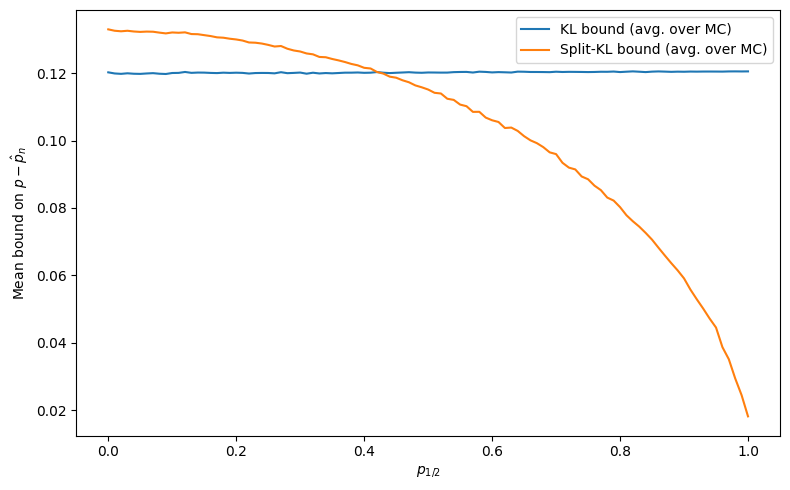

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

# parameters
n, delta = 100, 0.05
K = 2                      # number of non-trivial thresholds (0.5 and 1)
p_mid_grid = np.linspace(0, 1, 101)
M = 200                    # Monte Carlo repetitions per grid point

# KL divergence
def kl_div(p_hat, q):
    first  = p_hat * np.log(p_hat/q)       if p_hat > 0 else 0.0
    second = (1-p_hat) * np.log((1-p_hat)/(1-q)) if p_hat < 1 else 0.0
    return first + second

# Inverse KL (upper) via binary search → largest q >= p_hat s.t. kl(p_hat‖q) <= eps
def kl_inv(p_hat, eps, tol=1e-10):
    if p_hat >= 1.0:
        return 1.0
    low, high = p_hat, 1.0
    while high - low > tol:
        mid = 0.5*(low + high)
        if kl_div(p_hat, mid) > eps:
            high = mid
        else:
            low = mid
    return low

# epsilons for the two bounds
epsilon_kl = np.log(1/delta) / n      # standard kl
epsilon_sp = np.log(K/delta) / n      # split-KL union bound with K=2

# storage
kl_bounds = np.zeros_like(p_mid_grid)
sp_bounds = np.zeros_like(p_mid_grid)

for idx, p_mid in enumerate(p_mid_grid):
    p0 = (1 - p_mid) / 2
    
    kl_vals = []
    sp_vals = []
    for _ in range(M):
        # draw sample
        sample = np.random.choice([0.0, 0.5, 1.0], size=n, p=[p0, p_mid, p0])
        hat = sample.mean()
        
        # standard KL bound on p - hat:
        q = kl_inv(hat, epsilon_kl)
        kl_vals.append(max(q - hat, 0))
        
        # split-KL: thresholds at 0.5, 1.0  → binary indicators
        h1 = (sample >= 0.5).mean()
        h2 = (sample >= 1.0).mean()
        q1 = kl_inv(h1, epsilon_sp)
        q2 = kl_inv(h2, epsilon_sp)
        # b0=0, b1=0.5, b2=1.0  ⇒ α1=b1−b0=0.5, α2=b2−b1=0.5
        sp_vals.append(max(0.5*q1 + 0.5*q2 - hat, 0))
    
    kl_bounds[idx] = np.mean(kl_vals)
    sp_bounds[idx] = np.mean(sp_vals)

# plot
plt.figure(figsize=(8,5))
plt.plot(p_mid_grid, kl_bounds, label='KL bound (avg. over MC)')
plt.plot(p_mid_grid, sp_bounds, label='Split-KL bound (avg. over MC)')
plt.xlabel('$p_{1/2}$')
plt.ylabel('Mean bound on $p - \\hat p_n$')
plt.legend()
plt.tight_layout()
plt.show()


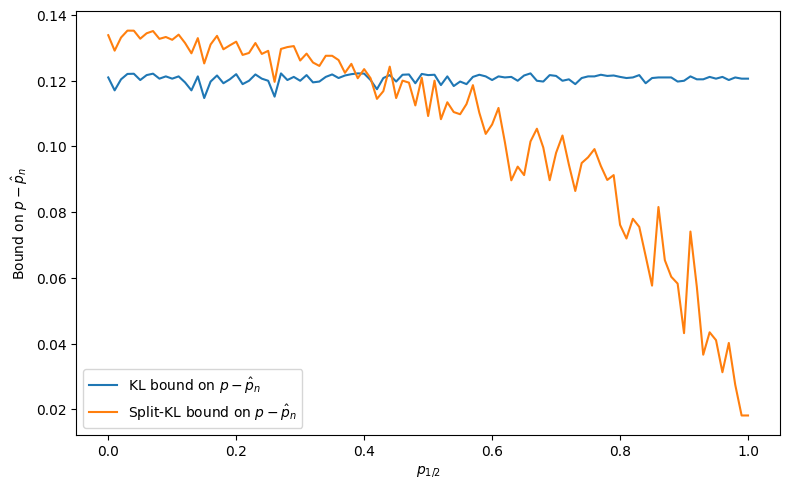

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

# parameters
n, delta = 100, 0.05
K = 2
p_mid_grid = np.linspace(0, 1, 101)

# KL helpers (same as above)
def kl_div(p_hat, q):
    first  = p_hat * np.log(p_hat/q)       if p_hat > 0 else 0.0
    second = (1-p_hat) * np.log((1-p_hat)/(1-q)) if p_hat < 1 else 0.0
    return first + second

def kl_inv(p_hat, eps, tol=1e-10):
    if p_hat >= 1.0:
        return 1.0
    low, high = p_hat, 1.0
    while high - low > tol:
        mid = 0.5*(low + high)
        if kl_div(p_hat, mid) > eps:
            high = mid
        else:
            low = mid
    return low

# epsilons
epsilon_kl = np.log(1/delta) / n
epsilon_sp = np.log(K/delta) / n

# storage
kl_diff = np.zeros_like(p_mid_grid)
sp_diff = np.zeros_like(p_mid_grid)

for idx, p_mid in enumerate(p_mid_grid):
    p0 = (1 - p_mid) / 2
    # one sample per grid point
    sample = np.random.choice([0.0, 0.5, 1.0], size=n, p=[p0, p_mid, p0])
    hat = sample.mean()
    
    # standard KL
    q = kl_inv(hat, epsilon_kl)
    kl_diff[idx] = max(q - hat, 0)
    
    # split-KL
    h1 = (sample >= 0.5).mean()
    h2 = (sample >= 1.0).mean()
    q1 = kl_inv(h1, epsilon_sp)
    q2 = kl_inv(h2, epsilon_sp)
    sp_diff[idx] = max(0.5*q1 + 0.5*q2 - hat, 0)

# plot
plt.figure(figsize=(8,5))
plt.plot(p_mid_grid, kl_diff, label='KL bound on $p-\\hat p_n$')
plt.plot(p_mid_grid, sp_diff, label='Split-KL bound on $p-\\hat p_n$')
plt.xlabel('$p_{1/2}$')
plt.ylabel('Bound on $p - \\hat p_n$')
plt.legend()
plt.tight_layout()
plt.show()


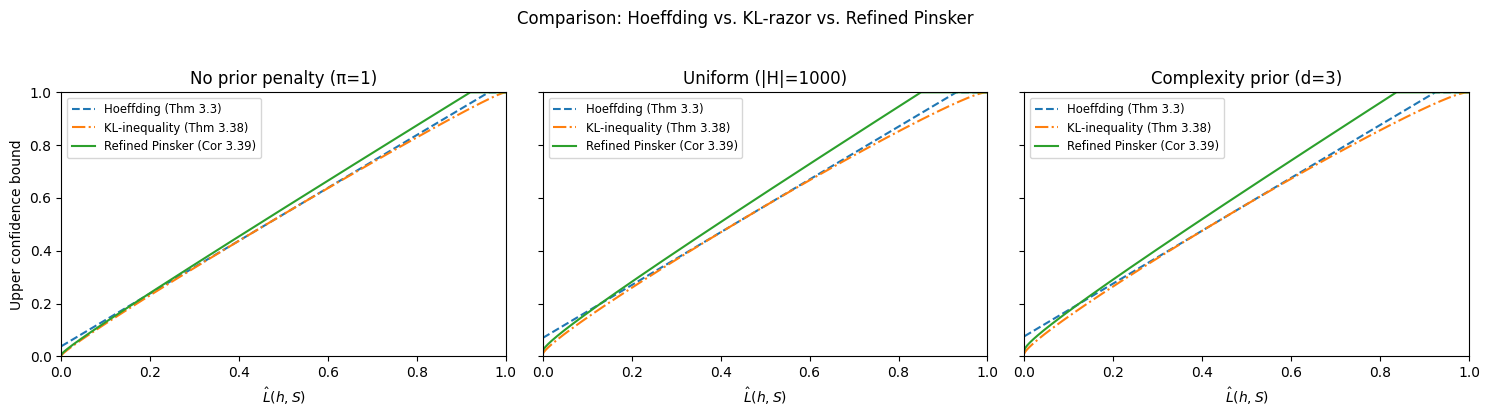

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 1000
delta = 0.05

# Prior settings
priors = {
    "No prior penalty (π=1)": np.log(1 / delta),
    "Uniform (|H|=1000)": np.log(1000 / delta),
    "Complexity prior (d=3)": np.log((3 * 4 * 2**(3**2)) / delta)
}

# Define loss grid
p_hats = np.linspace(0, 1, 500)

# KL divergence
def kl_div(p, q):
    if p == 0:
        term1 = 0.0
    else:
        term1 = p * np.log(p / q)
    if p == 1:
        term2 = 0.0
    else:
        term2 = (1 - p) * np.log((1 - p) / (1 - q))
    return term1 + term2

# Inversion for KL bound
def kl_upper(p_hat, C, n=n, tol=1e-8):
    if p_hat >= 1.0:
        return 1.0
    eps = C / n
    low, high = p_hat, 1.0
    while high - low > tol:
        mid = (low + high) / 2
        if kl_div(p_hat, mid) > eps:
            high = mid
        else:
            low = mid
    return low

# Bound functions
def hoeffding_bound(p_hat, C):
    return p_hat + np.sqrt(C / (2 * n))

def klrazor_bound(p_hat, C):
    return kl_upper(p_hat, C)

def refined_pinsker_bound(p_hat, C):
    return p_hat + np.sqrt((2 * p_hat * C) / n) + 2 * (C / n)

# Plotting
fig, axs = plt.subplots(1, len(priors), figsize=(15, 4), sharey=True)

for ax, (title, C) in zip(axs, priors.items()):
    hoeff = np.clip([hoeffding_bound(p, C) for p in p_hats], 0, 1)
    klraz = np.clip([klrazor_bound(p, C) for p in p_hats], 0, 1)
    refined = np.clip([refined_pinsker_bound(p, C) for p in p_hats], 0, 1)

    ax.plot(p_hats, hoeff, linestyle='--', label="Hoeffding (Thm 3.3)")
    ax.plot(p_hats, klraz, linestyle='-.', label="KL‐inequality (Thm 3.38)")
    ax.plot(p_hats, refined, linestyle='-', label="Refined Pinsker (Cor 3.39)")
    ax.set_title(title)
    ax.set_xlabel(r"$\hat L(h,S)$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize='small')

axs[0].set_ylabel("Upper confidence bound")
fig.suptitle("Comparison: Hoeffding vs. KL‐razor vs. Refined Pinsker", y=1.03)
plt.tight_layout()
plt.show()
